In [ ]:
# =============================================================================
# AI INFRASTRUCTURE — FOUNDATIONAL DATA PULLS & VISUALIZATIONS
# Run locally in Jupyter or as a script.
# Install: pip install pandas matplotlib seaborn requests
# Data: Alpha Vantage (free key at alphavantage.co — 25 calls/day on free tier)
# =============================================================================


# =============================================================================
# CELL 1 — IMPORTS, CONFIG & API KEY
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import time
import warnings
warnings.filterwarnings("ignore")

# !! REPLACE WITH YOUR NEW KEY !!
AV_KEY = ""
AV_BASE = "https://www.alphavantage.co/query"

# Plot style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 5)})

# Universe — grouped by stack layer
UNIVERSE = {
    "Accelerators":  ["NVDA", "AMD", "AVGO"],
    "Networking":    ["ANET", "CSCO"],
    "Servers":       ["SMCI", "DELL", "HPE"],
    "Hyperscalers":  ["MSFT", "AMZN", "GOOGL", "META"],
    "Power":         ["CEG", "VST", "NRG"],
    "Power Equip":   ["VRT", "ETN"],
    "Colocation":    ["EQIX", "DLR"],
}
ALL_TICKERS = [t for tickers in UNIVERSE.values() for t in tickers]


In [5]:
# =============================================================================
# CELL 2 — ALPHA VANTAGE PRICE PULL (monthly, adjusted close)
# Free tier: 25 calls/day — this pulls all 19 tickers so spread across 2 days
# if on the free tier, or upgrade to premium ($50/mo) for unlimited calls.
# Tip: run once, save to CSV, reload from CSV on subsequent runs.
# =============================================================================

def fetch_monthly_av(ticker, api_key, retries=3):
    """Pull monthly adjusted close from Alpha Vantage. Returns a Series."""
    params = {
        "function": "TIME_SERIES_MONTHLY_ADJUSTED",
        "symbol": ticker,
        "apikey": api_key,
        "outputsize": "full",
    }
    for attempt in range(retries):
        try:
            r = requests.get(AV_BASE, params=params, timeout=15)
            data = r.json()
            if "Monthly Adjusted Time Series" not in data:
                print(f"  {ticker}: unexpected response — {list(data.keys())}")
                return None
            series = data["Monthly Adjusted Time Series"]
            s = pd.Series(
                {pd.to_datetime(k): float(v["5. adjusted close"])
                 for k, v in series.items()}
            ).sort_index()
            return s
        except Exception as e:
            print(f"  {ticker} attempt {attempt+1} failed: {e}")
            time.sleep(2)
    return None

def load_prices(tickers, api_key, cache_file="price_cache.csv"):
    """
    Load from cache CSV if it exists, otherwise pull from Alpha Vantage.
    Re-pull only when you want fresh data by deleting price_cache.csv.
    """
    import os
    if os.path.exists(cache_file):
        print(f"Loading from cache: {cache_file}")
        return pd.read_csv(cache_file, index_col=0, parse_dates=True)

    print("Pulling from Alpha Vantage (this may take a few minutes)...")
    frames = {}
    for i, ticker in enumerate(tickers):
        print(f"  [{i+1}/{len(tickers)}] {ticker}")
        s = fetch_monthly_av(ticker, api_key)
        if s is not None:
            frames[ticker] = s
        # AV free tier: max 5 calls/min — sleep between calls
        time.sleep(13)

    df = pd.DataFrame(frames).sort_index()
    df.to_csv(cache_file)
    print(f"Saved to {cache_file}")
    return df

# --- Pull or load prices ---
prices = load_prices(ALL_TICKERS, AV_KEY)

# Filter to last 2 years
prices = prices[prices.index >= prices.index.max() - pd.DateOffset(years=2)]
print(f"\nLoaded {len(prices.columns)} tickers, {len(prices)} months")
print(prices.tail(3))

Pulling from Alpha Vantage (this may take a few minutes)...
  [1/19] NVDA
  [2/19] AMD
  [3/19] AVGO
  [4/19] ANET
  [5/19] CSCO
  [6/19] SMCI
  [7/19] DELL
  [8/19] HPE
  [9/19] MSFT
  [10/19] AMZN
  [11/19] GOOGL
  [12/19] META
  [13/19] CEG
  [14/19] VST
  [15/19] NRG
  [16/19] VRT
  [17/19] ETN
  [18/19] EQIX
  [19/19] DLR
Saved to price_cache.csv

Loaded 19 tickers, 25 months
                NVDA     AMD      AVGO    ANET      CSCO   SMCI    DELL  \
2026-05-29  210.8989  516.10  446.0307  159.47  119.9779  46.09  420.91   
2026-06-30  200.0900  580.91  377.7500  169.88  117.0288  29.33  431.46   
2026-07-15  212.5000  529.14  394.2800  171.92  111.7700  26.89  412.68   

                HPE    MSFT    AMZN     GOOGL     META      CEG       VST  \
2026-05-29  42.9136  450.24  270.64  380.1098  631.951  287.750  160.0109   
2026-06-30  45.1100  373.02  238.34  357.3700  563.290  248.370  158.6300   
2026-07-15  47.3900  395.63  254.96  370.9200  681.310  258.115  160.2300   

      

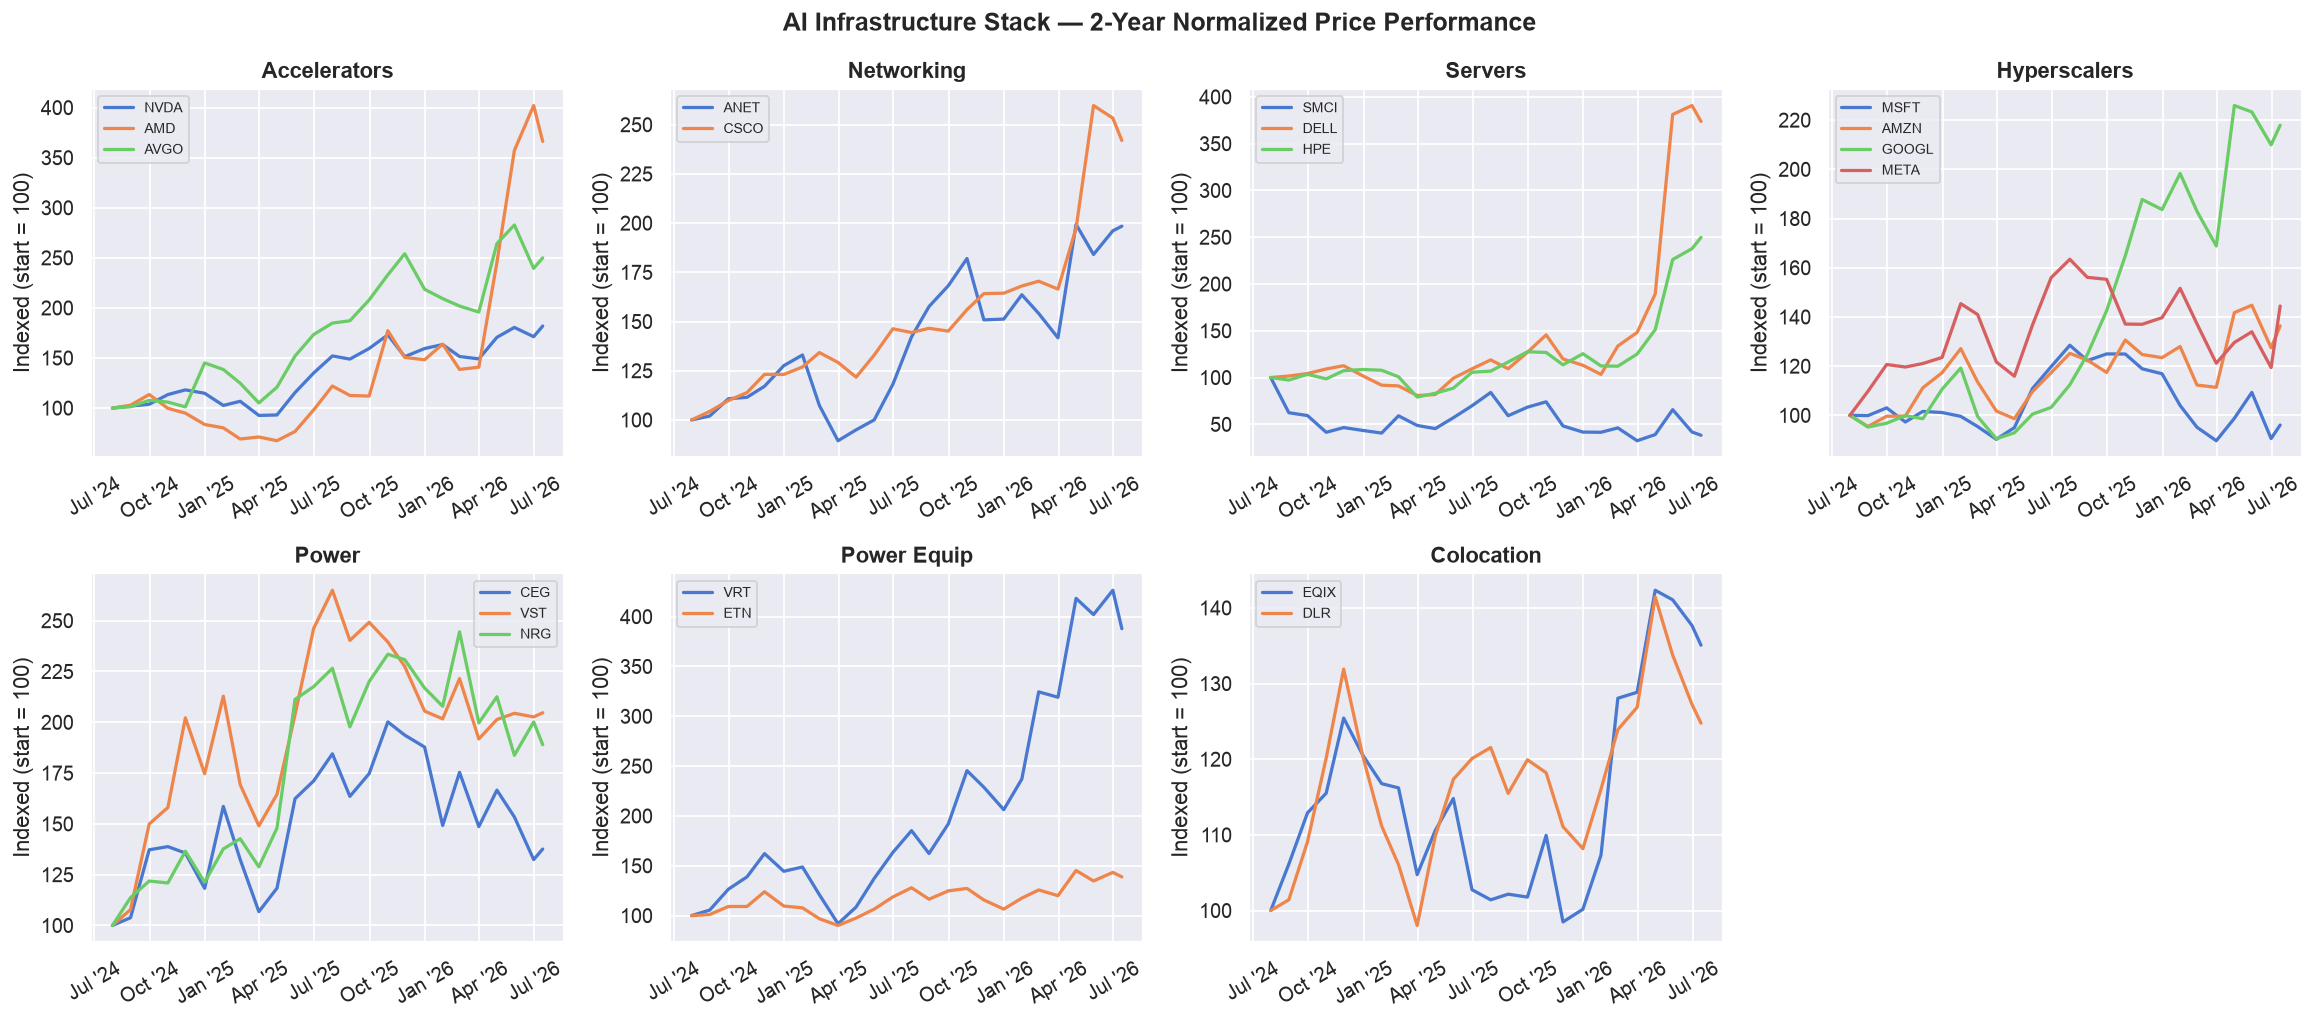

In [6]:
# =============================================================================
# CELL 3 — NORMALIZED PERFORMANCE BY STACK LAYER
# Normalize to 100 at start — apples-to-apples across layers
# What to look for: which layers led vs. lagged the AI buildout
# =============================================================================

normalized = (prices / prices.iloc[0]) * 100

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (layer, tickers) in enumerate(UNIVERSE.items()):
    ax = axes[i]
    for t in tickers:
        if t in normalized.columns:
            ax.plot(normalized.index, normalized[t], label=t, linewidth=1.8)
    ax.set_title(layer, fontweight="bold")
    ax.set_ylabel("Indexed (start = 100)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b '%y"))
    ax.tick_params(axis="x", rotation=30)

axes[-1].set_visible(False)
fig.suptitle("AI Infrastructure Stack — 2-Year Normalized Price Performance",
             fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig("01_stack_performance.png", bbox_inches="tight")
plt.show()

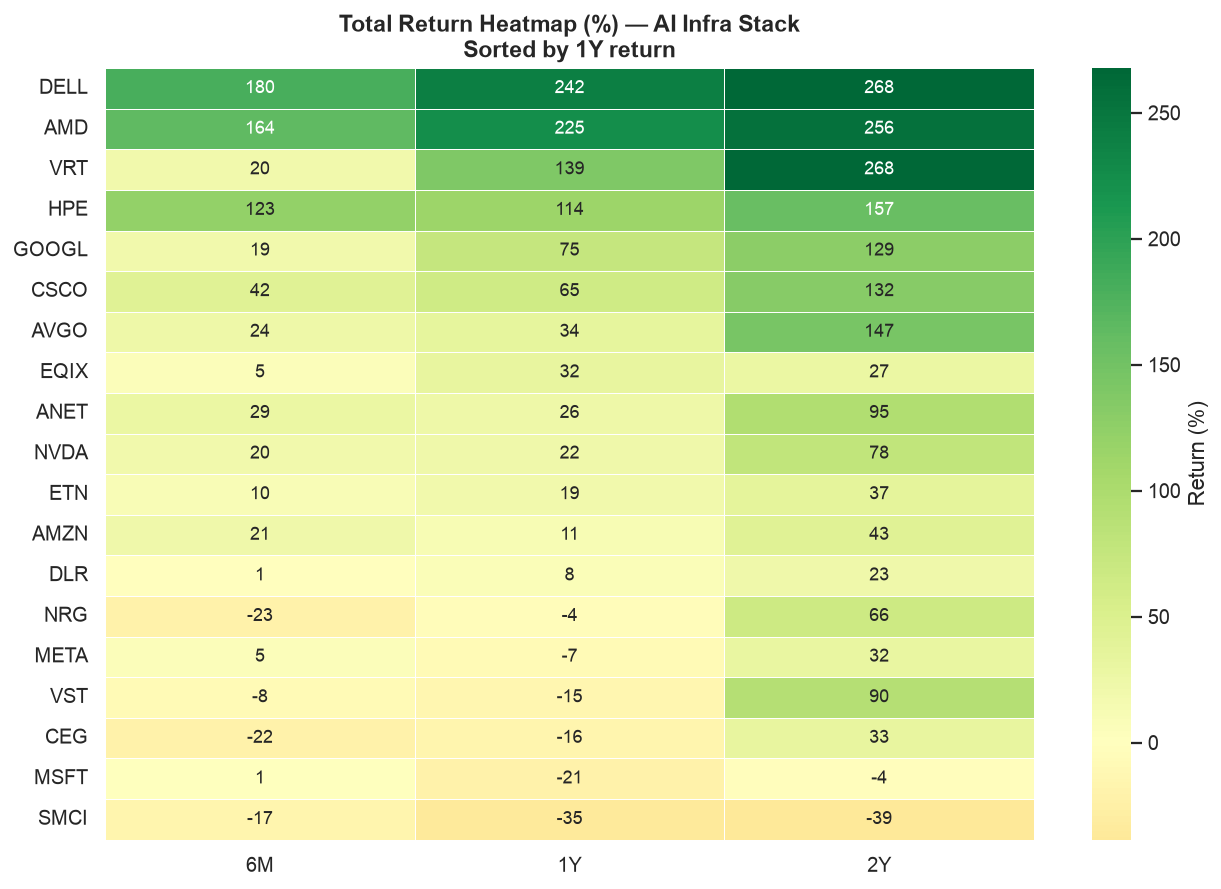

In [7]:
# =============================================================================
# CELL 4 — TOTAL RETURN HEATMAP (6M / 1Y / 2Y)
# What to look for: what's already run hard (crowded) vs. lagged (opportunity)
# =============================================================================

def period_return(df, months):
    subset = df.dropna(how="all").iloc[-months:]
    return ((subset.iloc[-1] / subset.iloc[0]) - 1) * 100

returns = pd.DataFrame({
    "6M":  period_return(prices, 6),
    "1Y":  period_return(prices, 12),
    "2Y":  period_return(prices, 24),
}).dropna().sort_values("1Y", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(returns[["6M","1Y","2Y"]].astype(float),
            annot=True, fmt=".0f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 10},
            cbar_kws={"label": "Return (%)"})
ax.set_title("Total Return Heatmap (%) — AI Infra Stack\nSorted by 1Y return",
             fontweight="bold", fontsize=13)
plt.tight_layout()
# plt.savefig("02_return_heatmap.png", bbox_inches="tight")
plt.show()

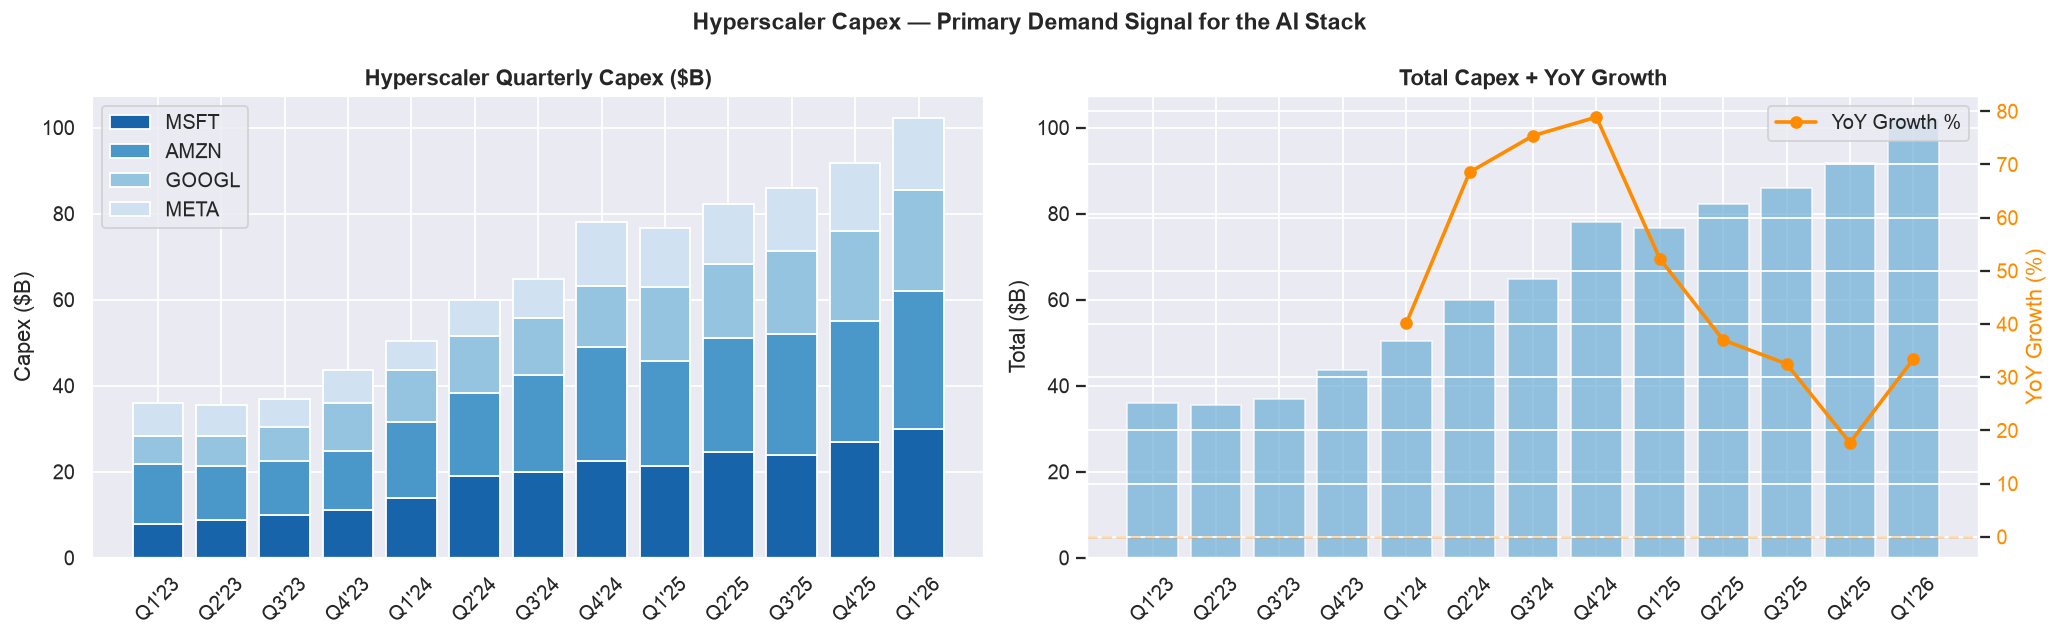

In [8]:
# =============================================================================
# CELL 5 — HYPERSCALER CAPEX (manually entered from 10-Q filings)
# This is the #1 demand signal — update every quarter from earnings releases
# Sources: MSFT/AMZN/GOOGL/META 10-Q filings; Q1'26 from May 2026 earnings
# =============================================================================

capex_data = {
    "Quarter": [
        "Q1'23","Q2'23","Q3'23","Q4'23",
        "Q1'24","Q2'24","Q3'24","Q4'24",
        "Q1'25","Q2'25","Q3'25","Q4'25",
        "Q1'26",
    ],
    "MSFT":  [7.8, 8.9, 9.9, 11.2, 14.0, 19.0, 20.0, 22.6, 21.4, 24.7, 24.0, 27.0, 30.0],
    "AMZN":  [14.1,12.5,12.5,13.7, 17.6, 19.3, 22.6, 26.3, 24.3, 26.3, 28.0, 28.0, 32.0],
    "GOOGL": [6.3, 6.9, 8.1, 11.0, 12.0, 13.2, 13.1, 14.3, 17.2, 17.2, 19.2, 21.0, 23.5],
    "META":  [7.7, 7.3, 6.5, 7.7,  6.7,  8.5,  9.2, 14.8, 13.7, 14.0, 14.8, 15.8, 16.7],
}

df_capex = pd.DataFrame(capex_data)
df_capex["Total"] = df_capex[["MSFT","AMZN","GOOGL","META"]].sum(axis=1)
yoy_growth = df_capex["Total"].pct_change(4) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar
bottom = np.zeros(len(df_capex))
for co, color in zip(["MSFT","AMZN","GOOGL","META"],
                      sns.color_palette("Blues_r", 4)):
    ax1.bar(df_capex["Quarter"], df_capex[co], bottom=bottom, label=co, color=color)
    bottom += df_capex[co].values
ax1.set_title("Hyperscaler Quarterly Capex ($B)", fontweight="bold")
ax1.set_ylabel("Capex ($B)")
ax1.legend()
ax1.tick_params(axis="x", rotation=45)

# Total + YoY growth
ax2.bar(df_capex["Quarter"], df_capex["Total"],
        color=sns.color_palette("Blues_r",1)[0], alpha=0.7)
ax2r = ax2.twinx()
ax2r.plot(df_capex["Quarter"], yoy_growth, color="darkorange",
          marker="o", linewidth=2, label="YoY Growth %")
ax2r.axhline(0, color="darkorange", linestyle="--", alpha=0.3)
ax2r.set_ylabel("YoY Growth (%)", color="darkorange")
ax2r.tick_params(axis="y", labelcolor="darkorange")
ax2.set_title("Total Capex + YoY Growth", fontweight="bold")
ax2.set_ylabel("Total ($B)")
ax2.tick_params(axis="x", rotation=45)
ax2r.legend()

fig.suptitle("Hyperscaler Capex — Primary Demand Signal for the AI Stack",
             fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig("03_hyperscaler_capex.png", bbox_inches="tight")
plt.show()

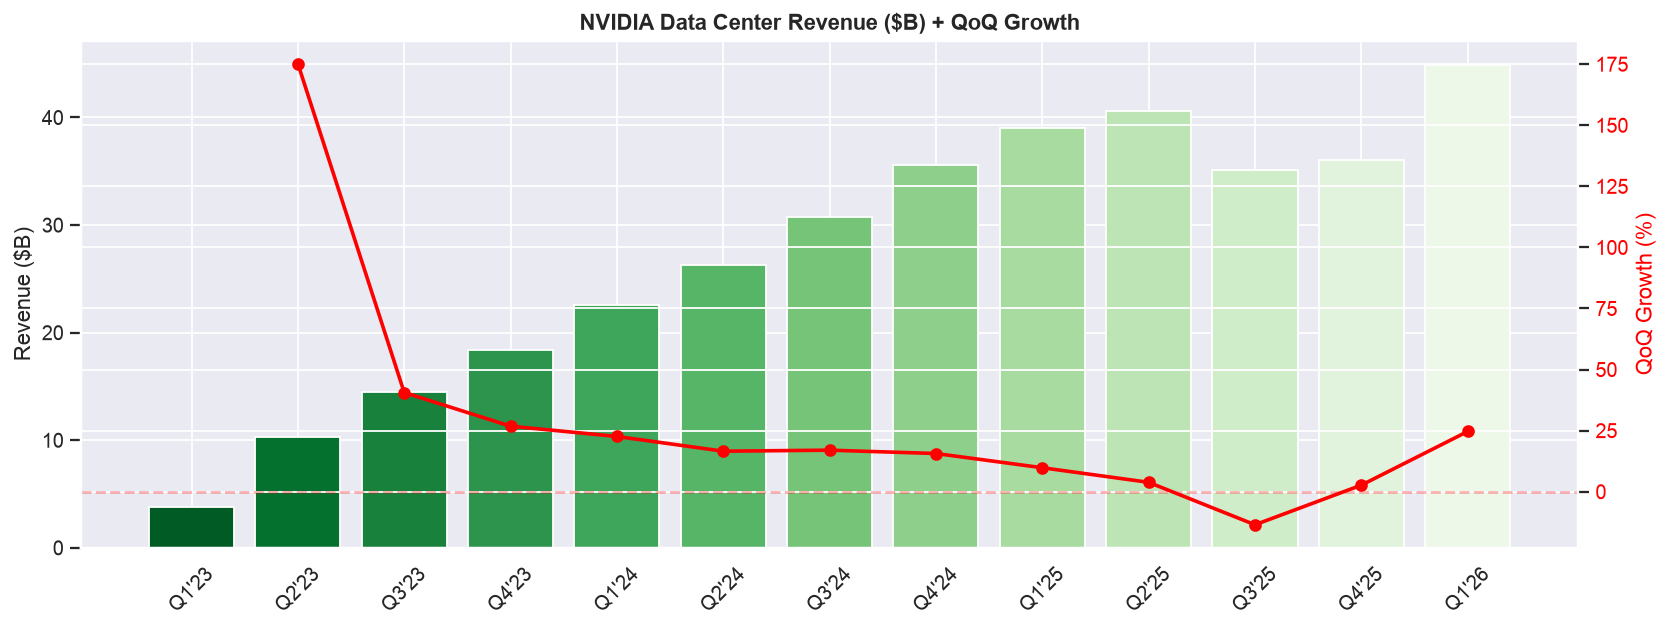

In [9]:
# =============================================================================
# CELL 6 — NVIDIA DATA CENTER REVENUE
# Source: NVIDIA earnings releases (fiscal year ends January)
# QoQ deceleration here = first warning sign for the whole stack
# =============================================================================

nvda_dc = {
    "Quarter":  ["Q1'23","Q2'23","Q3'23","Q4'23",
                 "Q1'24","Q2'24","Q3'24","Q4'24",
                 "Q1'25","Q2'25","Q3'25","Q4'25","Q1'26"],
    "DC_Rev_B": [3.75, 10.32, 14.51, 18.40,
                 22.56, 26.30, 30.77, 35.58,
                 39.07, 40.57, 35.08, 36.02, 44.90],
}

df_nvda = pd.DataFrame(nvda_dc)
df_nvda["QoQ_pct"] = df_nvda["DC_Rev_B"].pct_change() * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(df_nvda["Quarter"], df_nvda["DC_Rev_B"],
       color=sns.color_palette("Greens_r", len(df_nvda)), edgecolor="white")
ax2 = ax.twinx()
ax2.plot(df_nvda["Quarter"], df_nvda["QoQ_pct"],
         color="red", marker="o", linewidth=2)
ax2.axhline(0, color="red", linestyle="--", alpha=0.3)
ax2.set_ylabel("QoQ Growth (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax.set_title("NVIDIA Data Center Revenue ($B) + QoQ Growth",
             fontweight="bold", fontsize=12)
ax.set_ylabel("Revenue ($B)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
# plt.savefig("04_nvidia_dc_revenue.png", bbox_inches="tight")
plt.show()

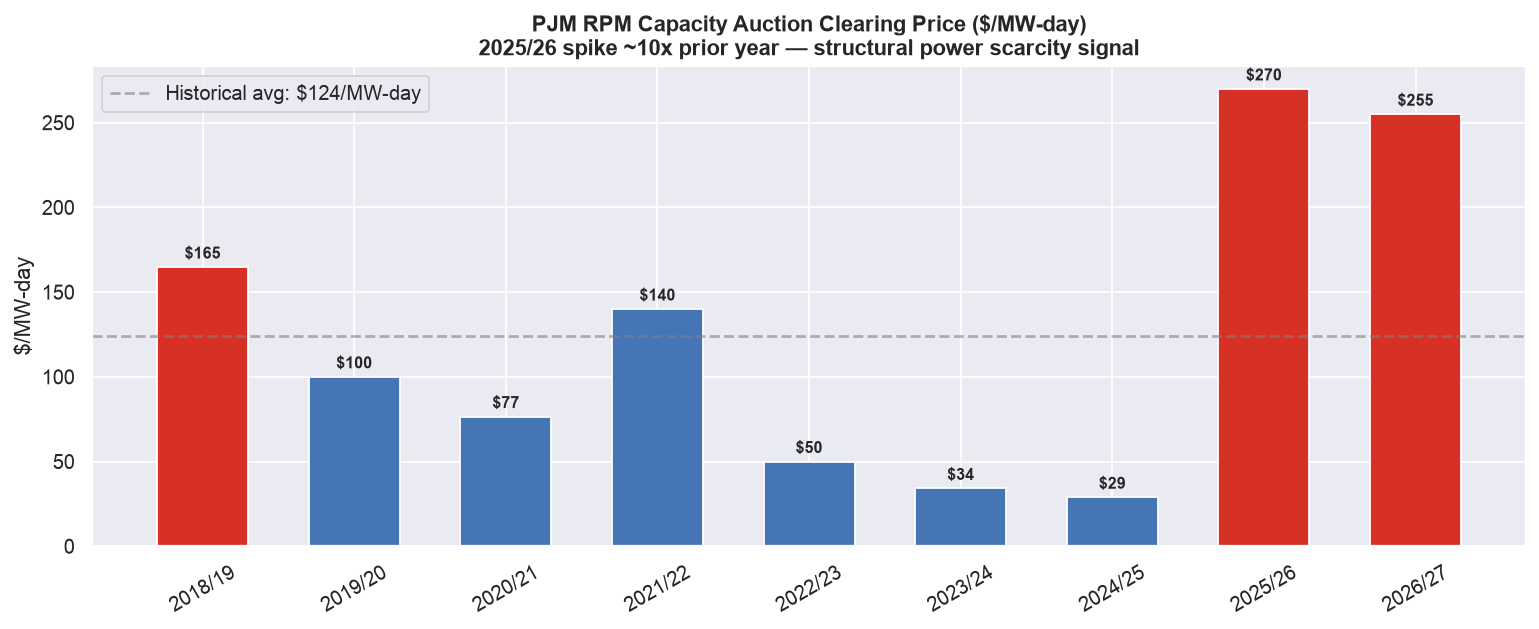

In [10]:
# =============================================================================
# CELL 7 — PJM CAPACITY AUCTION PRICES
# Source: PJM RPM auction results — public at pjm.com/markets-and-operations/rpm
# This is the earnings driver for CEG and VST
# =============================================================================

pjm_data = {
    "Delivery_Year": ["2018/19","2019/20","2020/21","2021/22",
                      "2022/23","2023/24","2024/25","2025/26","2026/27"],
    "Price_MW_day":  [164.77, 100.00, 76.53, 140.00,
                      50.00, 34.13, 28.92, 269.92, 255.00],
}

df_pjm = pd.DataFrame(pjm_data)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#d73027" if p > 150 else "#4575b4" for p in df_pjm["Price_MW_day"]]
bars = ax.bar(df_pjm["Delivery_Year"], df_pjm["Price_MW_day"],
              color=colors, edgecolor="white", width=0.6)
ax.axhline(df_pjm["Price_MW_day"].mean(), color="gray",
           linestyle="--", alpha=0.6, label=f"Historical avg: ${df_pjm['Price_MW_day'].mean():.0f}/MW-day")
for bar, p in zip(bars, df_pjm["Price_MW_day"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"${p:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("PJM RPM Capacity Auction Clearing Price ($/MW-day)\n"
             "2025/26 spike ~10x prior year — structural power scarcity signal",
             fontweight="bold", fontsize=12)
ax.set_ylabel("$/MW-day")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
# plt.savefig("05_pjm_capacity_prices.png", bbox_inches="tight")
plt.show()




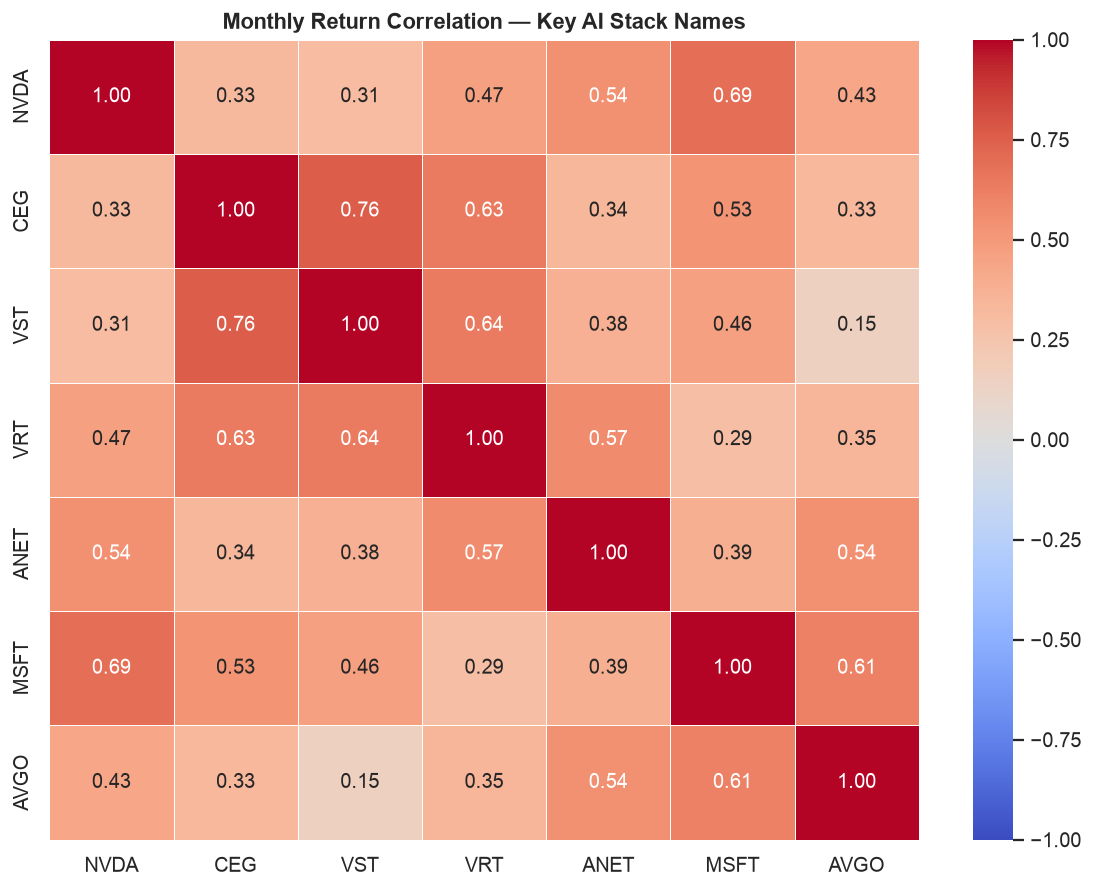

In [11]:
# =============================================================================
# CELL 8 — CORRELATION MATRIX
# Monthly return correlations across key names
# High NVDA <-> power stock correlation = they trade as one AI theme
# A breakdown in correlation = theme fragmentation / rotation signal
# =============================================================================

corr_tickers = ["NVDA", "CEG", "VST", "VRT", "ANET", "MSFT", "AVGO"]
corr_data = prices[[t for t in corr_tickers if t in prices.columns]].dropna()
corr_matrix = corr_data.pct_change().dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, annot_kws={"size": 11})
ax.set_title("Monthly Return Correlation — Key AI Stack Names",
             fontweight="bold", fontsize=12)
plt.tight_layout()
# plt.savefig("06_correlation_matrix.png", bbox_inches="tight")
plt.show()

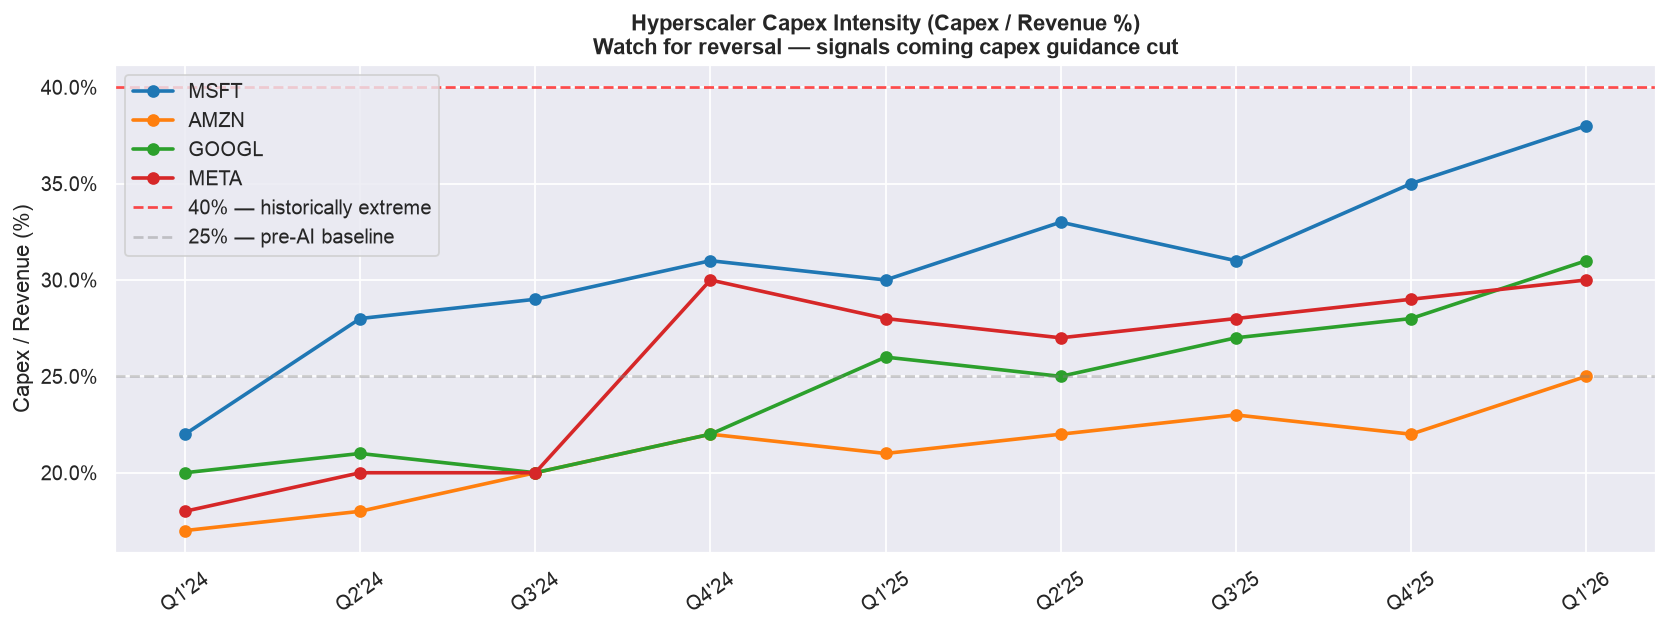

In [12]:
# =============================================================================
# CELL 9 — CAPEX INTENSITY (capex / revenue %)
# Tracks how much of revenue hyperscalers are plowing back into buildout
# >40% historically extreme — watch for CFO pushback / capex guidance cut
# Source: quarterly 10-Q filings (manually maintained)
# =============================================================================

intensity_data = {
    "Quarter": ["Q1'24","Q2'24","Q3'24","Q4'24",
                "Q1'25","Q2'25","Q3'25","Q4'25","Q1'26"],
    "MSFT":    [22, 28, 29, 31, 30, 33, 31, 35, 38],
    "AMZN":    [17, 18, 20, 22, 21, 22, 23, 22, 25],
    "GOOGL":   [20, 21, 20, 22, 26, 25, 27, 28, 31],
    "META":    [18, 20, 20, 30, 28, 27, 28, 29, 30],
}

df_int = pd.DataFrame(intensity_data)

fig, ax = plt.subplots(figsize=(13, 5))
for co, color in zip(["MSFT","AMZN","GOOGL","META"],
                      sns.color_palette("tab10", 4)):
    ax.plot(df_int["Quarter"], df_int[co], marker="o",
            label=co, linewidth=2, color=color)
ax.axhline(40, color="red", linestyle="--", alpha=0.7, label="40% — historically extreme")
ax.axhline(25, color="gray", linestyle="--", alpha=0.4, label="25% — pre-AI baseline")
ax.set_title("Hyperscaler Capex Intensity (Capex / Revenue %)\n"
             "Watch for reversal — signals coming capex guidance cut",
             fontweight="bold", fontsize=12)
ax.set_ylabel("Capex / Revenue (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.tight_layout()
# plt.savefig("07_capex_intensity.png", bbox_inches="tight")
plt.show()

In [13]:
# =============================================================================
# CELL 10 — KEY SIGNALS SUMMARY
# =============================================================================

print("\n=== CHARTS SAVED ===")
charts = [
    ("01_stack_performance.png",  "2Y normalized returns by layer"),
    ("02_return_heatmap.png",     "6M/1Y/2Y return heatmap"),
    ("03_hyperscaler_capex.png",  "Quarterly capex + YoY growth"),
    ("04_nvidia_dc_revenue.png",  "GPU demand pulse"),
    ("05_pjm_capacity_prices.png","Power scarcity / CEG+VST earnings driver"),
    ("06_correlation_matrix.png", "Theme cohesion signal"),
    ("07_capex_intensity.png",    "CFO pushback early warning"),
]
for fname, desc in charts:
    print(f"  {fname:35s} {desc}")

print("\n=== KEY SIGNALS TO MONITOR ===")
signals = [
    ("Hyperscaler capex guidance (quarterly)", "Demand signal for everything below"),
    ("NVIDIA DC revenue QoQ",                  "First place GPU softening shows up"),
    ("PJM capacity auction price",             "Primary earnings driver for CEG & VST"),
    ("Capex intensity crossing 40%",           "Risk of sudden capex pullback"),
    ("NVDA <-> power stock correlation",       "Break = theme fragmentation / rotation"),
    ("TSMC monthly revenue",                   "Leading indicator on wafer starts"),
    ("ASML quarterly order intake",            "12-18 month fab capex leading indicator"),
]
print(f"  {'Signal':<45} {'Why It Matters'}")
print(f"  {'-'*44} {'-'*35}")
for signal, why in signals:
    print(f"  {signal:<45} {why}")


=== CHARTS SAVED ===
  01_stack_performance.png            2Y normalized returns by layer
  02_return_heatmap.png               6M/1Y/2Y return heatmap
  03_hyperscaler_capex.png            Quarterly capex + YoY growth
  04_nvidia_dc_revenue.png            GPU demand pulse
  05_pjm_capacity_prices.png          Power scarcity / CEG+VST earnings driver
  06_correlation_matrix.png           Theme cohesion signal
  07_capex_intensity.png              CFO pushback early warning

=== KEY SIGNALS TO MONITOR ===
  Signal                                        Why It Matters
  -------------------------------------------- -----------------------------------
  Hyperscaler capex guidance (quarterly)        Demand signal for everything below
  NVIDIA DC revenue QoQ                         First place GPU softening shows up
  PJM capacity auction price                    Primary earnings driver for CEG & VST
  Capex intensity crossing 40%                  Risk of sudden capex pullback
  NVDA <-> po